In [3]:
! pip install selenium beautifulsoup4 pandas numpy requests lxml openpyxl

In [4]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
import time

options = Options()
options.add_argument("--start-maximized")

service = Service()
driver = webdriver.Chrome(service=service, options=options)


In [5]:
url = "https://www.nabis.go.kr/termsDetailView.do?menucd=189&gbnCode=S51&eventNo=371"
driver.get(url)
time.sleep(3)  


연도별 평균과 합계:
        충전량 합계(Wh)                   방전량 합계(Wh)              
              mean            sum          mean           sum
연도                                                           
2023  2.139446e+08   778330512734  1.890869e+08  687898011560
2024  2.224539e+08  1036190252919  1.969840e+08  917551360147

강원도 연도별 평균과 합계:
        충전량 합계(Wh)                 방전량 합계(Wh)             
              mean          sum          mean          sum
연도                                                        
2023  2.859693e+08  61197423597  2.524046e+08  54014589854
2024  2.872708e+08  78712191155  2.538585e+08  69557222433


C:\Users\dkreh\AppData\Local\Temp\ipykernel_8840\1342493429.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gangwon_df['거래일'] = pd.to_datetime(gangwon_df['거래일'])
C:\Users\dkreh\AppData\Local\Temp\ipykernel_8840\1342493429.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gangwon_df['연도'] = gangwon_df['거래일'].dt.year


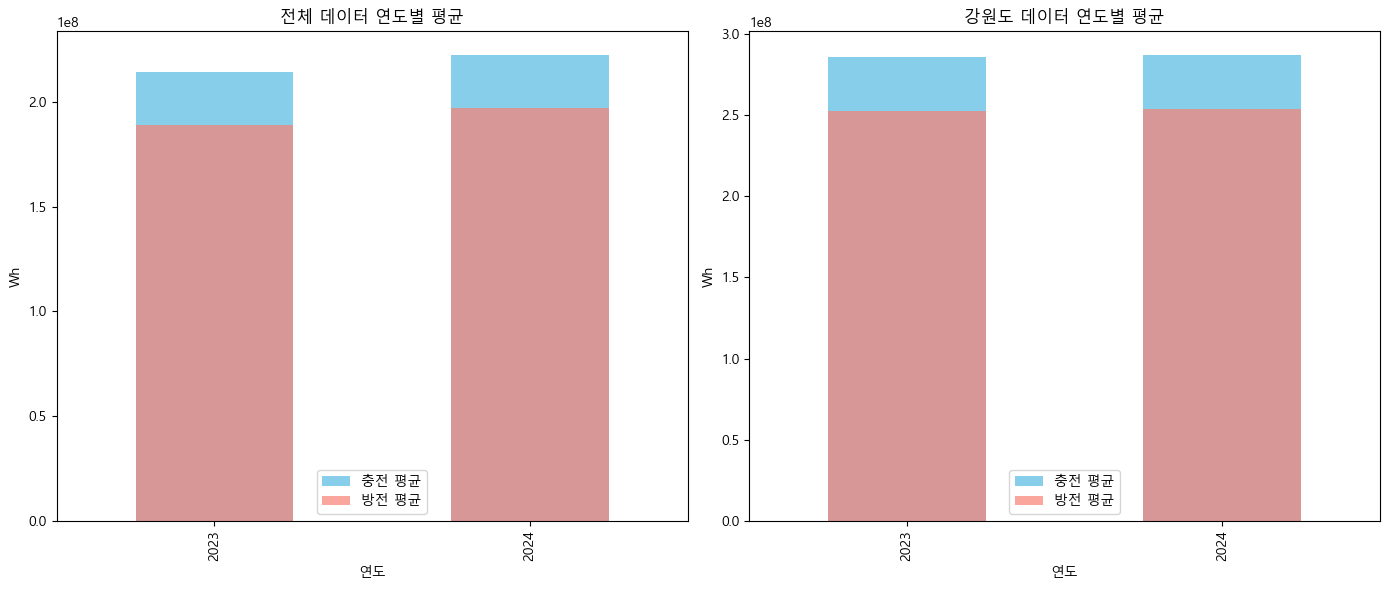

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우 기본 한글 폰트 (맑은 고딕)
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/policy/한국전력거래소_지역별 에너지저장장치(ESS) 일단위 충전 및 방전 실적_20240930.csv")

# 강원도 데이터만 필터링
gangwon_df = df[df['지역'] == '강원도']

# 거래일을 datetime 형식으로 변환
df['거래일'] = pd.to_datetime(df['거래일'])

# 연도 컬럼 추가
df['연도'] = df['거래일'].dt.year

# 연도별 평균과 합계 계산
yearly_stats = df.groupby('연도')[['충전량 합계(Wh)', '방전량 합계(Wh)']].agg(['mean', 'sum'])

print("연도별 평균과 합계:")
print(yearly_stats)

# 강원도만 따로 연도별 평균과 합계 계산
gangwon_df['거래일'] = pd.to_datetime(gangwon_df['거래일'])
gangwon_df['연도'] = gangwon_df['거래일'].dt.year
gangwon_stats = gangwon_df.groupby('연도')[['충전량 합계(Wh)', '방전량 합계(Wh)']].agg(['mean', 'sum'])

print("\n강원도 연도별 평균과 합계:")
print(gangwon_stats)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14,6))

yearly_stats['충전량 합계(Wh)']['mean'].plot(kind='bar', ax=axes[0], color='skyblue', label='충전 평균')
yearly_stats['방전량 합계(Wh)']['mean'].plot(kind='bar', ax=axes[0], color='salmon', alpha=0.7, label='방전 평균')
axes[0].set_title('전체 데이터 연도별 평균')
axes[0].set_ylabel('Wh')
axes[0].legend()

gangwon_stats['충전량 합계(Wh)']['mean'].plot(kind='bar', ax=axes[1], color='skyblue', label='충전 평균')
gangwon_stats['방전량 합계(Wh)']['mean'].plot(kind='bar', ax=axes[1], color='salmon', alpha=0.7, label='방전 평균')
axes[1].set_title('강원도 데이터 연도별 평균')
axes[1].set_ylabel('Wh')
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 불러오기
df = pd.read_csv(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/policy/한국전력거래소_지역별 에너지저장장치(ESS) 일단위 충전 및 방전 실적_20240930.csv")

# 강원도 데이터만 필터링 (copy로 경고 방지)
gangwon_df = df[df['지역'] == '강원도'].copy()

# 거래일을 datetime 형식으로 변환
df['거래일'] = pd.to_datetime(df['거래일'])
gangwon_df['거래일'] = pd.to_datetime(gangwon_df['거래일'])

# 연도 컬럼 추가
df['연도'] = df['거래일'].dt.year
gangwon_df['연도'] = gangwon_df['거래일'].dt.year

# 연도별 평균과 합계 계산
yearly_stats = df.groupby('연도')[['충전량 합계(Wh)', '방전량 합계(Wh)']].agg(['mean', 'sum'])
gangwon_stats = gangwon_df.groupby('연도')[['충전량 합계(Wh)', '방전량 합계(Wh)']].agg(['mean', 'sum'])

print("연도별 평균과 합계:")
print(yearly_stats)

print("\n강원도 연도별 평균과 합계:")
print(gangwon_stats)

연도별 평균과 합계:
        충전량 합계(Wh)                   방전량 합계(Wh)              
              mean            sum          mean           sum
연도                                                           
2023  2.139446e+08   778330512734  1.890869e+08  687898011560
2024  2.224539e+08  1036190252919  1.969840e+08  917551360147

강원도 연도별 평균과 합계:
        충전량 합계(Wh)                 방전량 합계(Wh)             
              mean          sum          mean          sum
연도                                                        
2023  2.859693e+08  61197423597  2.524046e+08  54014589854
2024  2.872708e+08  78712191155  2.538585e+08  69557222433


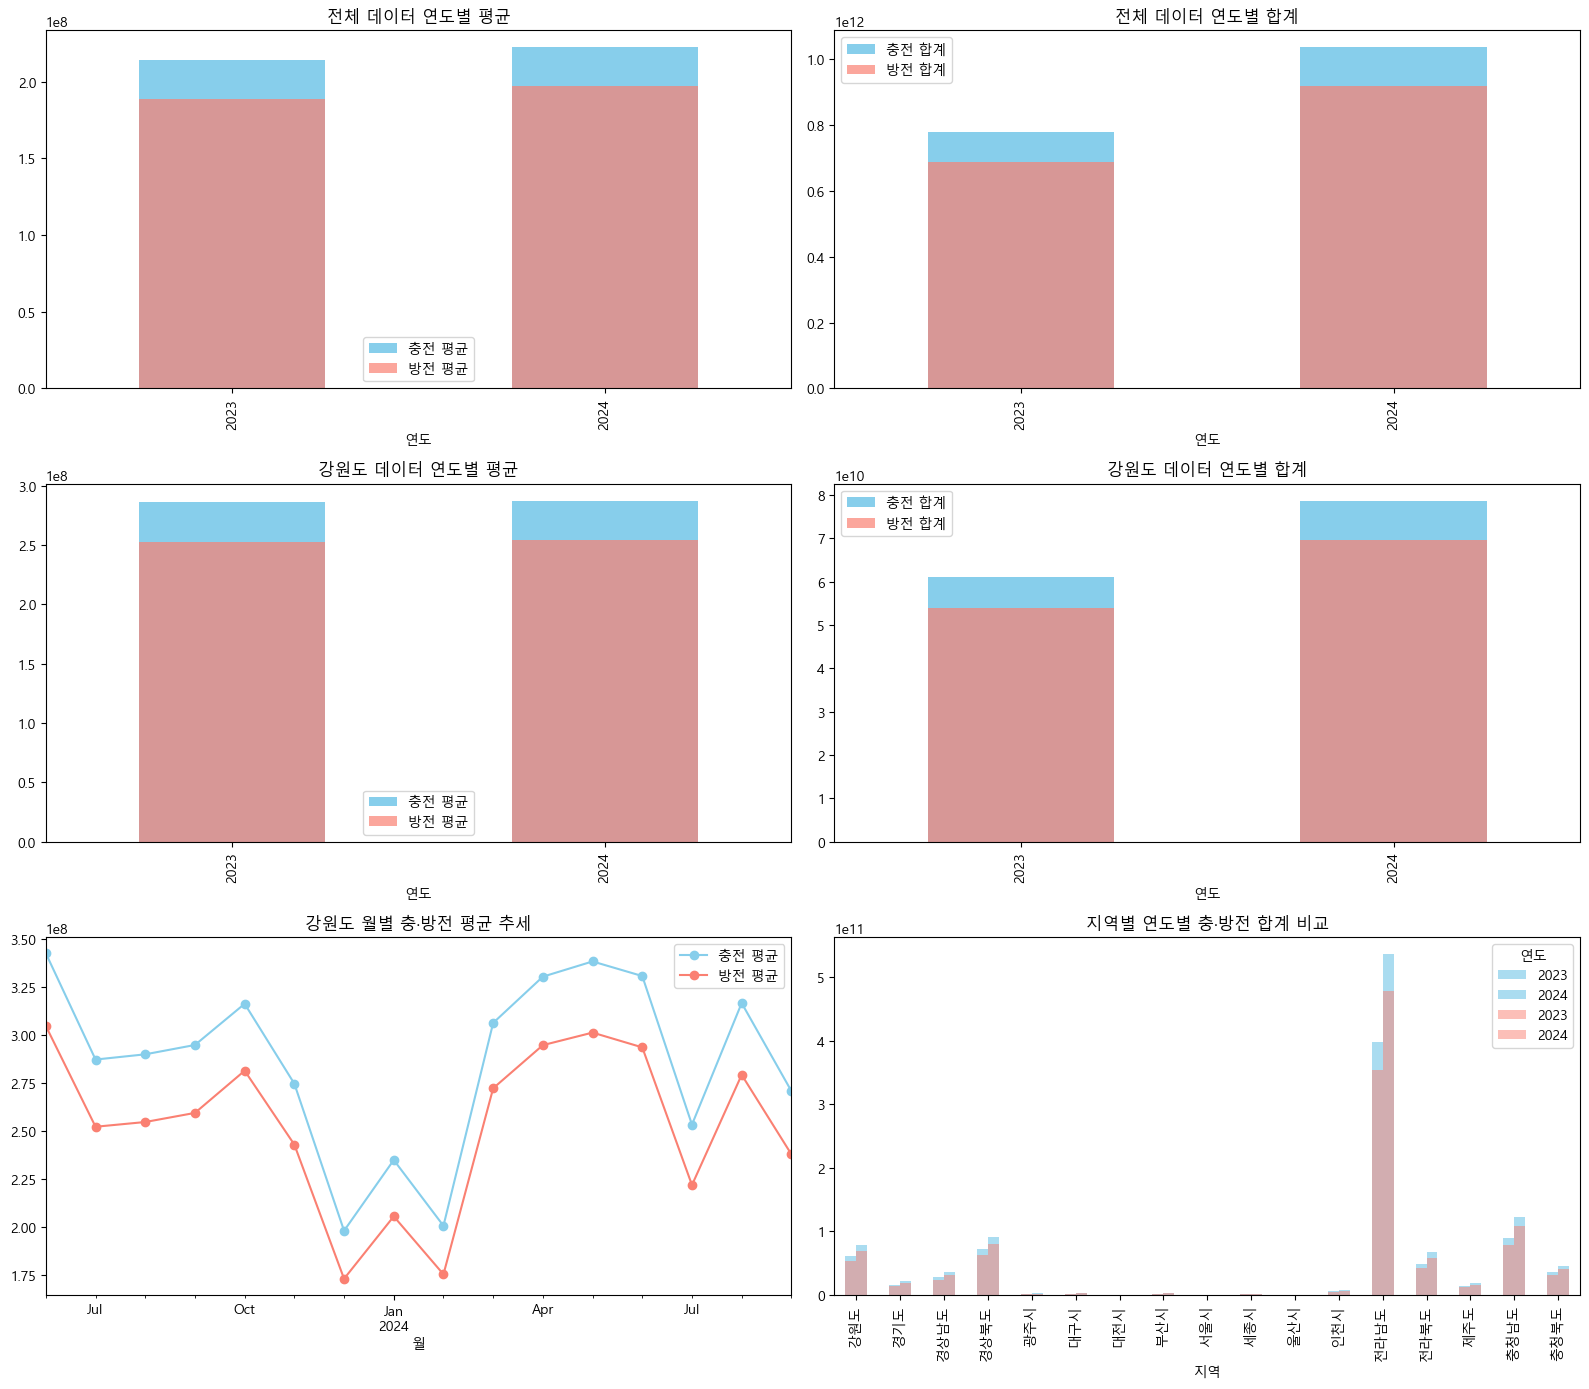

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 불러오기
df = pd.read_csv(r"C:/Users/dkreh/Desktop/KDT_RE_5th/3_Project/01_DataAnalysis/data/policy/한국전력거래소_지역별 에너지저장장치(ESS) 일단위 충전 및 방전 실적_20240930.csv")

# 강원도 데이터만 필터링
gangwon_df = df[df['지역'] == '강원도'].copy()

# 거래일 datetime 변환
df['거래일'] = pd.to_datetime(df['거래일'])
gangwon_df['거래일'] = pd.to_datetime(gangwon_df['거래일'])

# 연도, 월 컬럼 추가
df['연도'] = df['거래일'].dt.year
df['월'] = df['거래일'].dt.to_period('M')
gangwon_df['연도'] = gangwon_df['거래일'].dt.year
gangwon_df['월'] = gangwon_df['거래일'].dt.to_period('M')

# 집계
yearly_stats = df.groupby('연도')[['충전량 합계(Wh)','방전량 합계(Wh)']].agg(['mean','sum'])
gangwon_stats = gangwon_df.groupby('연도')[['충전량 합계(Wh)','방전량 합계(Wh)']].agg(['mean','sum'])
monthly_gangwon = gangwon_df.groupby('월')[['충전량 합계(Wh)','방전량 합계(Wh)']].mean()
region_year_stats = df.groupby(['지역','연도'])[['충전량 합계(Wh)','방전량 합계(Wh)']].sum()

# ✅ 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 시각화 (3행 2열 레이아웃)
fig, axes = plt.subplots(3, 2, figsize=(16,14))

# 1. 전체 평균
yearly_stats['충전량 합계(Wh)']['mean'].plot(kind='bar', ax=axes[0,0], color='skyblue', label='충전 평균')
yearly_stats['방전량 합계(Wh)']['mean'].plot(kind='bar', ax=axes[0,0], color='salmon', alpha=0.7, label='방전 평균')
axes[0,0].set_title('전체 데이터 연도별 평균'); axes[0,0].legend()

# 2. 전체 합계
yearly_stats['충전량 합계(Wh)']['sum'].plot(kind='bar', ax=axes[0,1], color='skyblue', label='충전 합계')
yearly_stats['방전량 합계(Wh)']['sum'].plot(kind='bar', ax=axes[0,1], color='salmon', alpha=0.7, label='방전 합계')
axes[0,1].set_title('전체 데이터 연도별 합계'); axes[0,1].legend()

# 3. 강원도 평균
gangwon_stats['충전량 합계(Wh)']['mean'].plot(kind='bar', ax=axes[1,0], color='skyblue', label='충전 평균')
gangwon_stats['방전량 합계(Wh)']['mean'].plot(kind='bar', ax=axes[1,0], color='salmon', alpha=0.7, label='방전 평균')
axes[1,0].set_title('강원도 데이터 연도별 평균'); axes[1,0].legend()

# 4. 강원도 합계
gangwon_stats['충전량 합계(Wh)']['sum'].plot(kind='bar', ax=axes[1,1], color='skyblue', label='충전 합계')
gangwon_stats['방전량 합계(Wh)']['sum'].plot(kind='bar', ax=axes[1,1], color='salmon', alpha=0.7, label='방전 합계')
axes[1,1].set_title('강원도 데이터 연도별 합계'); axes[1,1].legend()

# 5. 강원도 월별 추세
monthly_gangwon['충전량 합계(Wh)'].plot(ax=axes[2,0], color='skyblue', marker='o', label='충전 평균')
monthly_gangwon['방전량 합계(Wh)'].plot(ax=axes[2,0], color='salmon', marker='o', label='방전 평균')
axes[2,0].set_title('강원도 월별 충·방전 평균 추세'); axes[2,0].legend()

# 6. 지역별 연도별 합계 비교
region_year_stats.unstack()['충전량 합계(Wh)'].plot(kind='bar', ax=axes[2,1], color='skyblue', alpha=0.7)
region_year_stats.unstack()['방전량 합계(Wh)'].plot(kind='bar', ax=axes[2,1], color='salmon', alpha=0.5)
axes[2,1].set_title('지역별 연도별 충·방전 합계 비교')

plt.tight_layout()
plt.show()